In [12]:
import pandas as pd

# The user provided the Excel file path.
file_path = '/HDR25_Statistical_Annex_HDI_Table.xlsx'

try:
    # Specify header=4 to correctly read the 5th row as column headers (0-indexed)
    df_hdi = pd.read_excel(file_path, header=4)
    print(f"Dataset '{file_path}' loaded successfully with header from row 5.")
    print("\nFirst 5 rows of the dataset:")
    display(df_hdi.head())
    print("\nDataset Information:")
    df_hdi.info()
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file name and path.")
    print("You might need to upload the file to `/content/` or specify the correct path and filename.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset '/HDR25_Statistical_Annex_HDI_Table.xlsx' loaded successfully with header from row 5.

First 5 rows of the dataset:


,Unnamed: 0,Unnamed: 1,Human Development Index (HDI),Unnamed: 3,Life expectancy at birth,Unnamed: 5,Expected years of schooling,Unnamed: 7,Mean years of schooling,Unnamed: 9,Gross national income (GNI) per capita,Unnamed: 11,GNI per capita rank minus HDI rank,Unnamed: 13,HDI rank
0,HDI rank,Country,Value,NaN,(years),NaN,(years),NaN,(years),NaN,(2021 PPP $),NaN,NaN,NaN,NaN
1,NaN,NaN,2023,NaN,2023,NaN,2023,a,2023,a,2023,NaN,2023,b,2022
2,NaN,Very high human development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Iceland,0.972,NaN,82.691,NaN,18.85059,c,13.908926,d,69116.93736,NaN,12,NaN,3
4,2,Norway,0.97,NaN,83.308,NaN,18.79285,c,13.117962,e,112710.0211,f,0,NaN,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Unnamed: 0                              194 non-null    object 
 1   Unnamed: 1                              264 non-null    object 
 2   Human Development Index (HDI)           212 non-null    object 
 3   Unnamed: 3                              0 non-null      float64
 4   Life expectancy at birth                212 non-null    object 
 5   Unnamed: 5                              3 non-null      object 
 6   Expected years of schooling             212 non-null    object 
 7   Unnamed: 7                              97 non-null     object 
 8   Mean years of schooling                 212 non-null    object 
 9   Unnamed: 9                              129 non-null    object 
 10  Gross national income (GNI) per capita  

With the dataset loaded, let's proceed to inspect the unique countries and prepare for visualization, assuming columns similar to an HDI dataset are present.

In [2]:
# Check for common country column names and display unique countries
country_cols = ['Country', 'country', 'Economy']
found_country_col = None

for col in country_cols:
    if col in df_hdi.columns:
        found_country_col = col
        break

if found_country_col:
    unique_countries = df_hdi[found_country_col].unique()
    print(f"Unique Countries/Economies ({len(unique_countries)}):")
    print(unique_countries[:20]) # Displaying first 20 unique entries
else:
    print("No common country column name ('Country', 'country', 'Economy') found in the dataset.")
    print("Available columns:", df_hdi.columns.tolist())
    print("Please identify the column that represents countries.")

No common country column name ('Country', 'country', 'Economy') found in the dataset.
Available columns: ['Unnamed: 0', 'Table 1. Human Development Index and its components', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']
Please identify the column that represents countries.


The column names are now correctly loaded. Let's clean them up by removing the year information in parentheses and select the relevant columns for analysis, focusing on the most recent data (2021).

In [16]:
import pandas as pd
import re

# Helper to clean column names
def clean_col_name(col_name):
    cleaned = str(col_name).strip()
    cleaned = re.sub(r'\s*\(\d{4}\)', '', cleaned)
    cleaned = re.sub(r'\s*\(.*?\)', '', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# Re-read to ensure fresh state
df_hdi = pd.read_excel('/HDR25_Statistical_Annex_HDI_Table.xlsx', header=4)
sub_headers = df_hdi.iloc[0]
new_cols = []

for i, col in enumerate(df_hdi.columns):
    sub = str(sub_headers.iloc[i]).strip() if pd.notna(sub_headers.iloc[i]) else ''

    if i == 0:
        new_cols.append('HDI rank')
    elif i == 1:
        new_cols.append('Country')
    elif i == 2:
        new_cols.append('Human Development Index')
    elif i == 4:
        new_cols.append('Life expectancy at birth')
    elif i == 6:
        new_cols.append('Expected years of schooling')
    elif i == 8:
        new_cols.append('Mean years of schooling')
    elif i == 10:
        new_cols.append('Gross national income per capita')
    else:
        # Append index to unnamed/duplicate columns to keep them unique
        base_name = clean_col_name(col) if 'Unnamed' not in str(col) else f'Extra_{i}'
        new_cols.append(base_name)

df_hdi.columns = new_cols
df_hdi = df_hdi.iloc[1:].copy()

# Filter out non-country rows
df_hdi = df_hdi.dropna(subset=['Country', 'HDI rank'])
df_hdi = df_hdi[~df_hdi['Country'].str.contains('development|Total|World', case=False, na=False)]

# Convert to numeric
numeric_cols = ['Human Development Index', 'Life expectancy at birth',
                'Expected years of schooling', 'Mean years of schooling', 'Gross national income per capita']

for col in numeric_cols:
    df_hdi[col] = pd.to_numeric(df_hdi[col], errors='coerce')

# Final selection
df_hdi_2021 = df_hdi[['Country'] + numeric_cols].copy()
print("Data cleaning complete. Shape:", df_hdi_2021.shape)
display(df_hdi_2021.head())

Data cleaning complete. Shape: (193, 6)


,Country,Human Development Index,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income per capita
3,Iceland,0.972,82.691,18.850590,13.908926,69116.93736
4,Norway,0.970,83.308,18.792850,13.117962,112710.02110
5,Switzerland,0.970,83.954,16.667530,13.949121,81948.90177
6,Denmark,0.962,81.933,18.704010,13.027321,76007.85669
7,Germany,0.959,81.378,17.309219,14.296372,64053.22124


Now that we have a cleaner dataset with relevant columns, let's perform some basic descriptive statistics and check for missing values in these key columns.

Unique Countries (193):
['Iceland' 'Norway' 'Switzerland' 'Denmark' 'Germany' 'Sweden' 'Australia'
 'Hong Kong, China (SAR)' 'Netherlands' 'Belgium' 'Ireland' 'Finland'
 'Singapore' 'United Kingdom' 'United Arab Emirates' 'Canada'
 'Liechtenstein' 'New Zealand' 'United States' 'Korea (Republic of)'
 'Slovenia' 'Austria' 'Japan' 'Malta' 'Luxembourg' 'France' 'Israel'
 'Spain' 'Czechia' 'Italy' 'San Marino' 'Andorra' 'Cyprus' 'Greece'
 'Poland' 'Estonia' 'Saudi Arabia' 'Bahrain' 'Lithuania' 'Portugal'
 'Croatia' 'Latvia' 'Qatar' 'Slovakia' 'Chile' 'Hungary' 'Argentina'
 'Montenegro' 'Uruguay' 'Oman' 'Türkiye' 'Kuwait' 'Antigua and Barbuda'
 'Seychelles' 'Bulgaria' 'Romania' 'Georgia' 'Saint Kitts and Nevis'
 'Panama' 'Brunei Darussalam' 'Kazakhstan' 'Costa Rica' 'Serbia'
 'Russian Federation' 'Belarus' 'Bahamas' 'Malaysia' 'North Macedonia'
 'Armenia' 'Barbados' 'Albania' 'Trinidad and Tobago' 'Mauritius'
 'Bosnia and Herzegovina' 'Iran (Islamic Republic of)'
 'Saint Vincent and the Gren

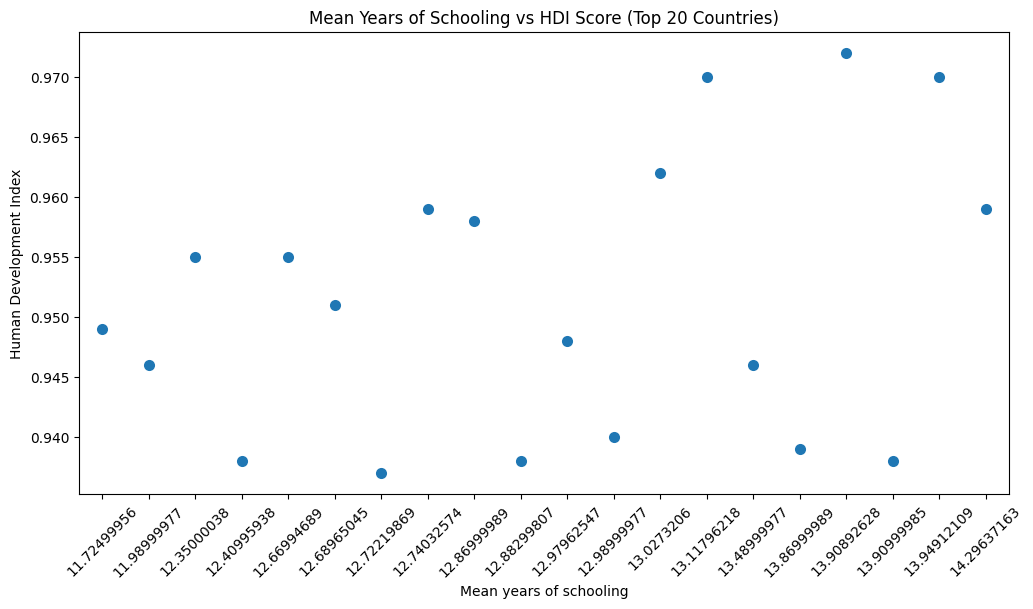

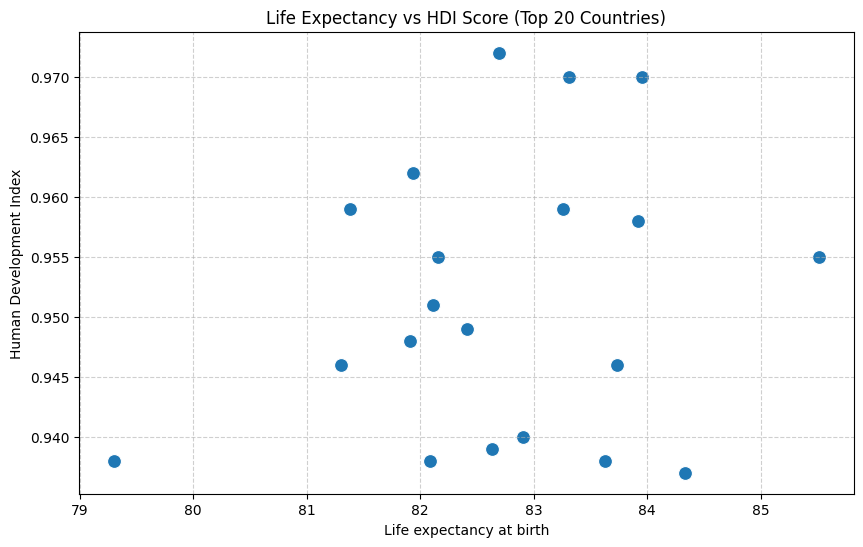

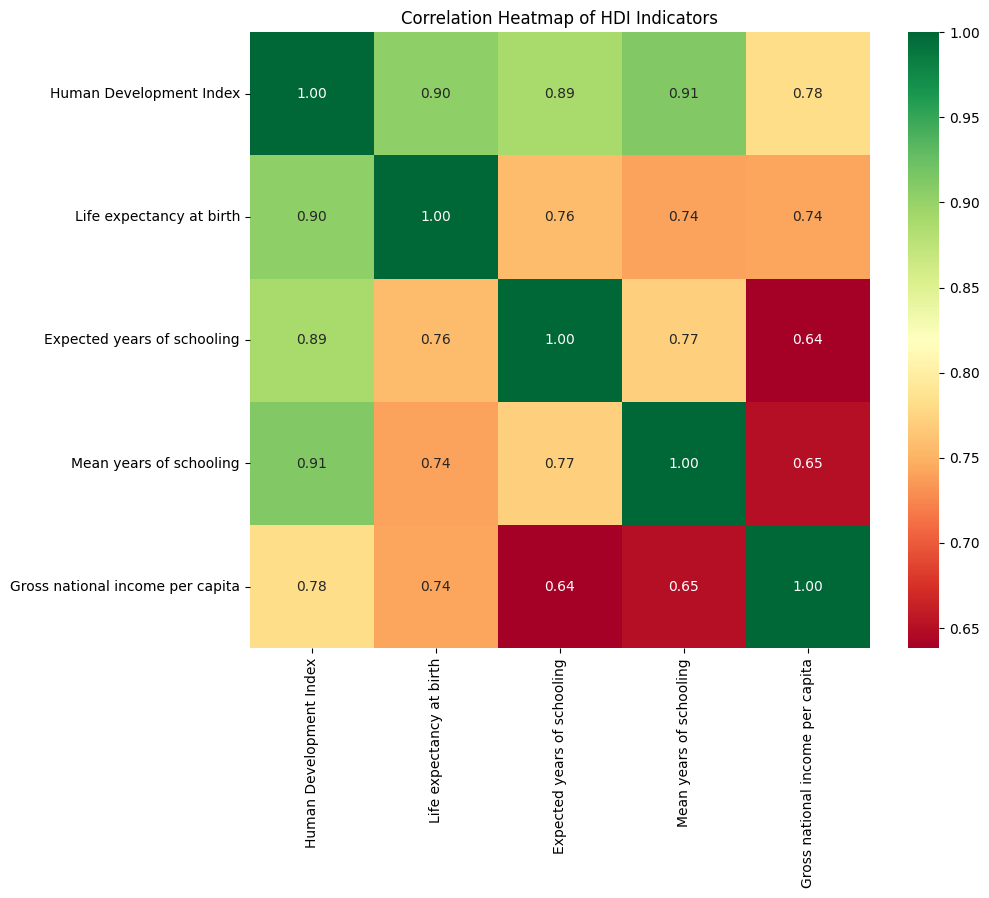

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Task 1: Unique Country Values
unique_countries = df_hdi_2021['Country'].unique()
print(f"Unique Countries ({len(unique_countries)}):")
print(unique_countries)

# Take first 20 rows for specific visualization tasks
data1 = df_hdi_2021.head(20)

# Task 2: Mean Years of Schooling vs HDI (Strip Plot)
plt.figure(figsize=(12, 6))
sns.stripplot(x='Mean years of schooling', y='Human Development Index', data=data1, size=8, jitter=True)
plt.title('Mean Years of Schooling vs HDI Score (Top 20 Countries)')
plt.xticks(rotation=45)
plt.show()

# Task 3: Life Expectancy vs HDI (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Life expectancy at birth', y='Human Development Index', data=data1, s=100)
plt.title('Life Expectancy vs HDI Score (Top 20 Countries)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Task 4: Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_hdi_2021.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of HDI Indicators')
plt.show()

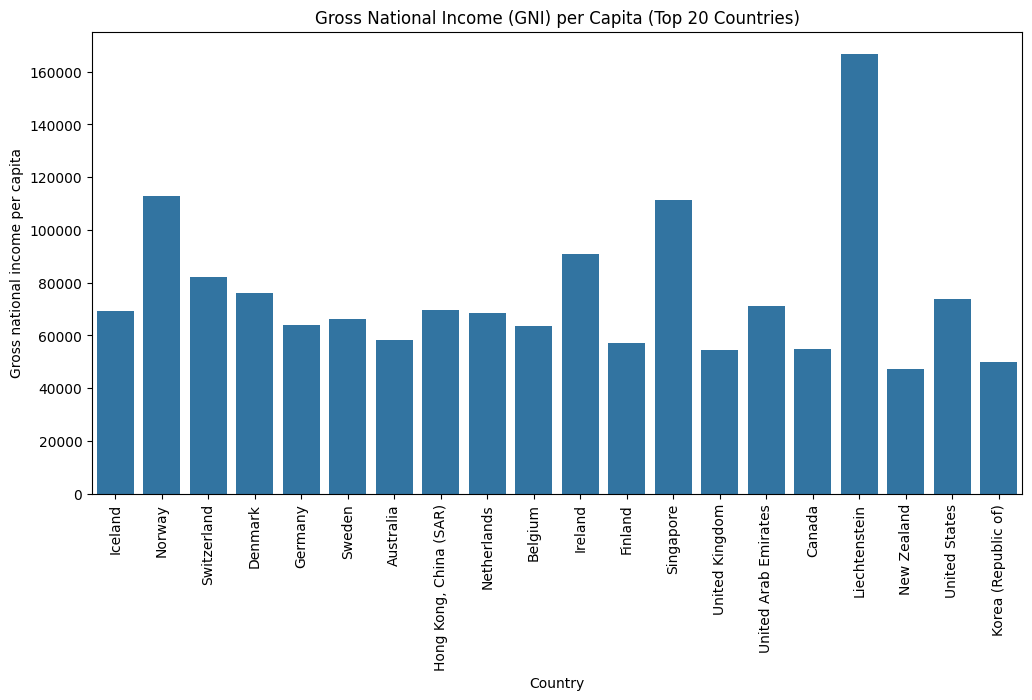

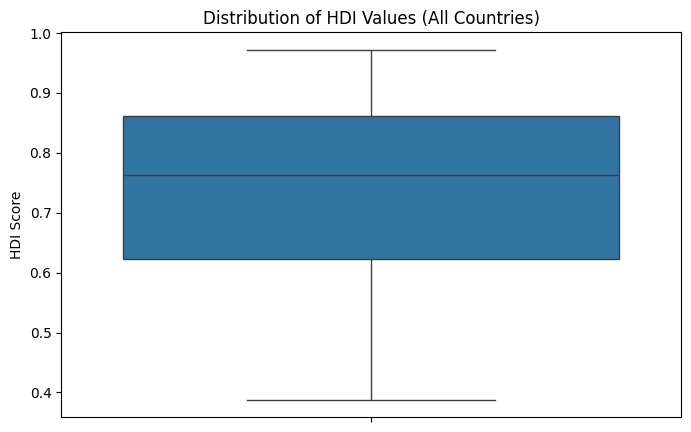

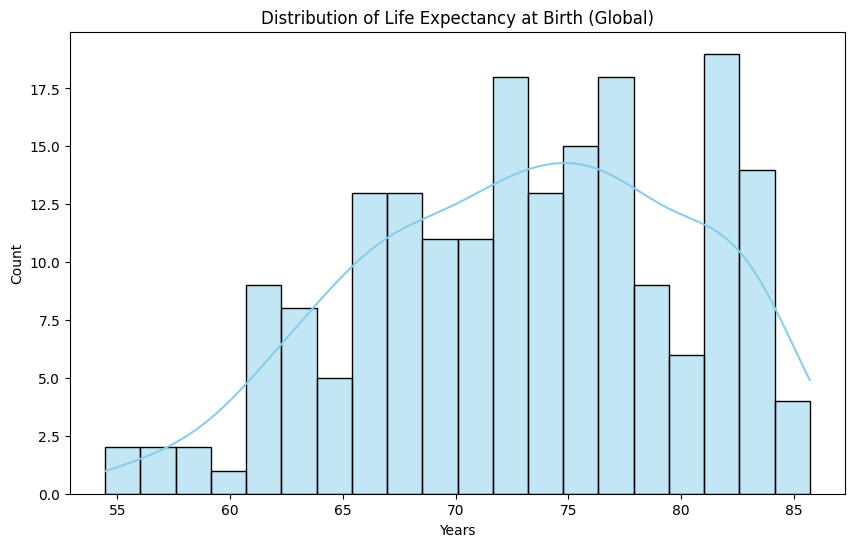

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data for the first 20 countries
data1 = df_hdi_2021.head(20)

# Task 5: Bar Plot of GNI per Capita
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Gross national income per capita', data=data1)
plt.title('Gross National Income (GNI) per Capita (Top 20 Countries)')
plt.xticks(rotation=90)
plt.show()

# Task 6: Box Plot of HDI Value Distribution
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_hdi_2021['Human Development Index'])
plt.title('Distribution of HDI Values (All Countries)')
plt.ylabel('HDI Score')
plt.show()

# Task 7: Distribution Plot (Histogram) of Life Expectancy
plt.figure(figsize=(10, 6))
sns.histplot(df_hdi_2021['Life expectancy at birth'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Life Expectancy at Birth (Global)')
plt.xlabel('Years')
plt.show()

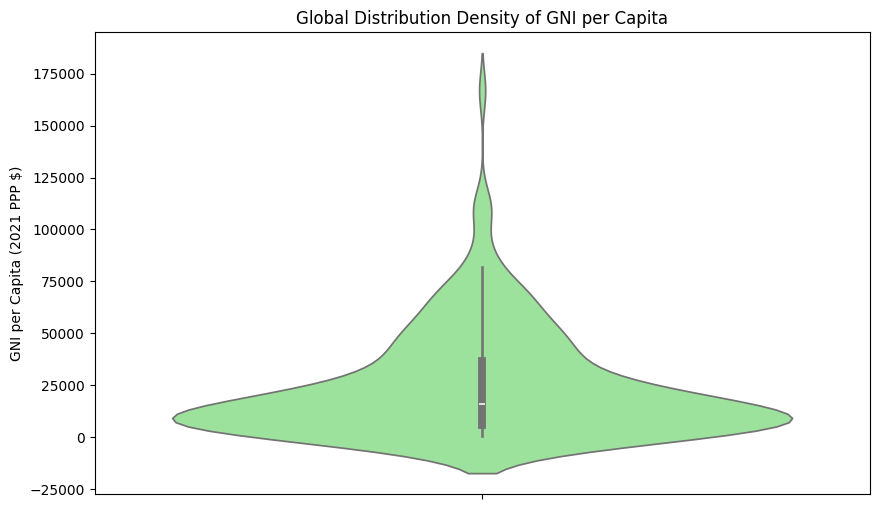

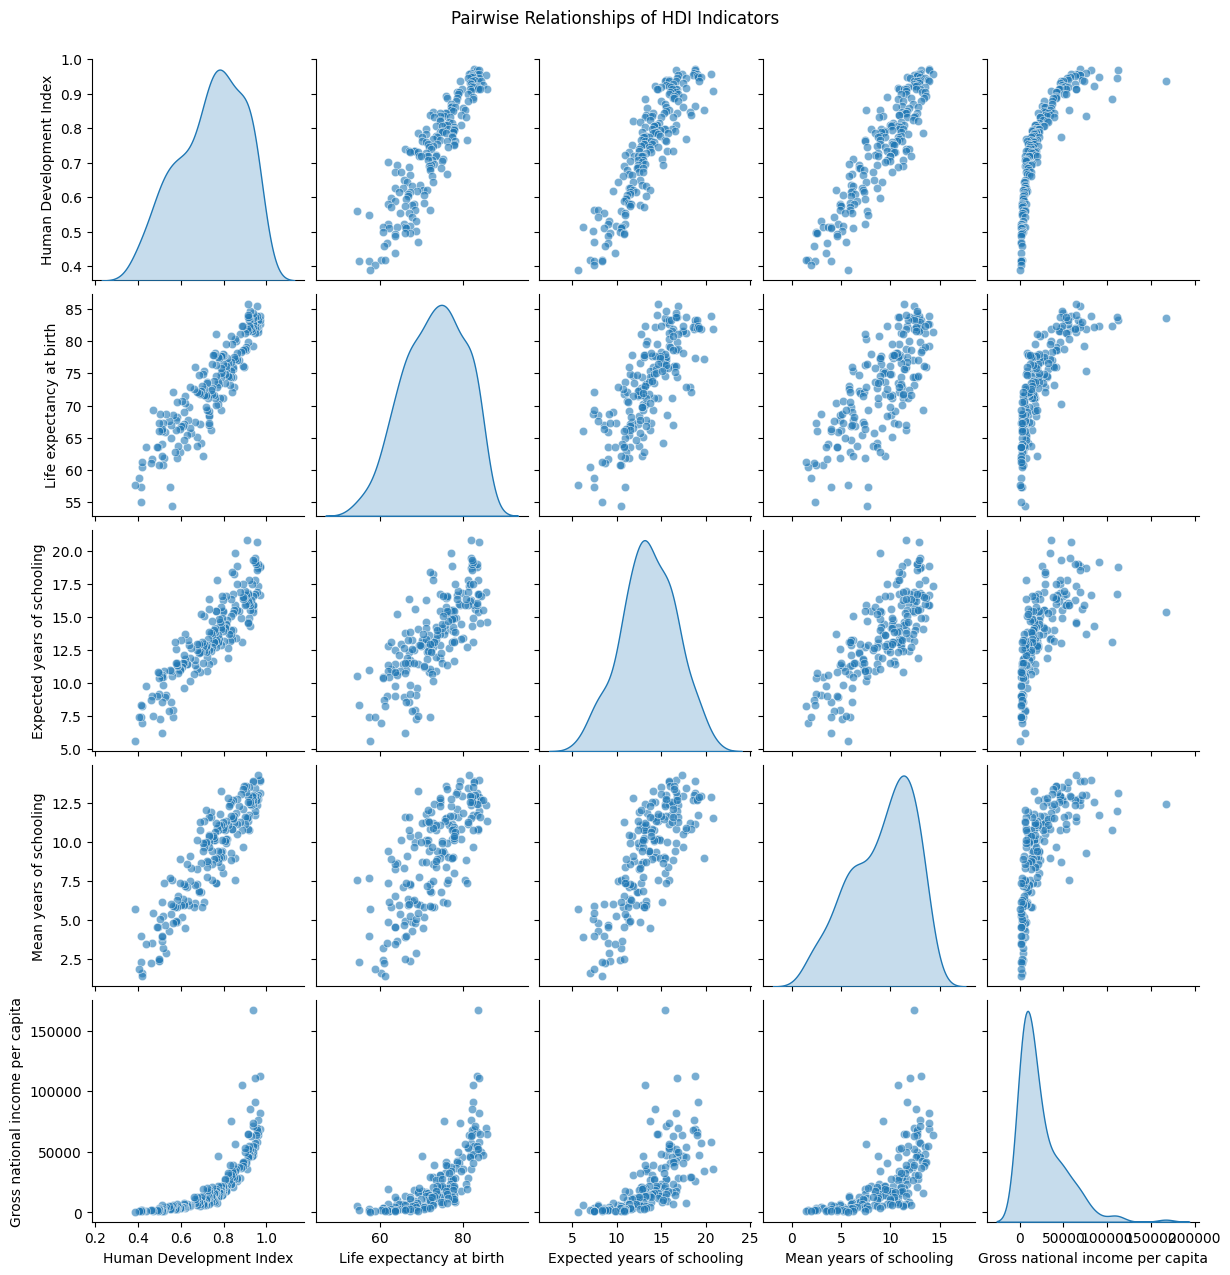

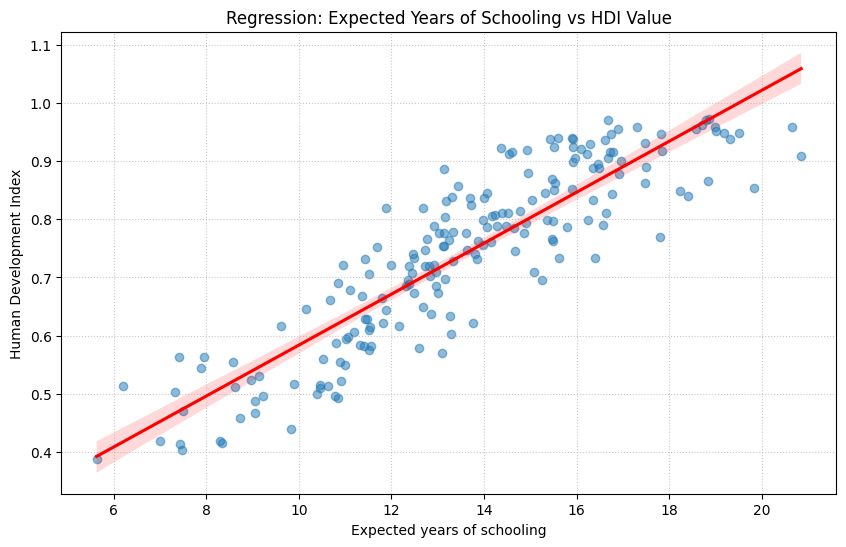

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data for top 20 for specific plots
data1 = df_hdi_2021.head(20)

# Task 8: Violin Plot of GNI per Capita (Global Distribution Density)
plt.figure(figsize=(10, 6))
sns.violinplot(y=df_hdi_2021['Gross national income per capita'], color='lightgreen')
plt.title('Global Distribution Density of GNI per Capita')
plt.ylabel('GNI per Capita (2021 PPP $)')
plt.show()

# Task 9: Pair Plot of all HDI Indicators
# This gives a comprehensive view of all pairwise relationships
sns.pairplot(df_hdi_2021, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships of HDI Indicators', y=1.02)
plt.show()

# Task 10: Regression Plot: Expected Schooling vs HDI Value
plt.figure(figsize=(10, 6))
sns.regplot(x='Expected years of schooling', y='Human Development Index', data=df_hdi_2021,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Regression: Expected Years of Schooling vs HDI Value')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Feature Selection and Data Imputation
We will now select the independent variables (Features) and the dependent variable (Target) for potential modeling. We will also handle missing values using the mean of each column.

In [20]:
# Select features (independent variables) and target (dependent variable)
# Using the cleaned DataFrame df_hdi_2021
# X: Indicators (Life Expectancy, Schooling, GNI)
# Y: Human Development Index

X = df_hdi_2021[['Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income per capita']]
y = df_hdi_2021['Human Development Index']

# Find Null Values
print("Missing values in independent variables (X):")
print(X.isnull().sum())

# Fill Null Values in X using column means
X = X.fillna(X.mean())

print("\nMissing values in X after imputation:")
print(X.isnull().sum())

# Display prepared features
display(X.head())

Missing values in independent variables (X):
Life expectancy at birth            0
Expected years of schooling         0
Mean years of schooling             0
Gross national income per capita    0
dtype: int64

Missing values in X after imputation:
Life expectancy at birth            0
Expected years of schooling         0
Mean years of schooling             0
Gross national income per capita    0
dtype: int64


,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income per capita
3,82.691,18.850590,13.908926,69116.93736
4,83.308,18.792850,13.117962,112710.02110
5,83.954,16.667530,13.949121,81948.90177
6,81.933,18.704010,13.027321,76007.85669
7,81.378,17.309219,14.296372,64053.22124


In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data successfully split into training ({len(X_train)} samples) and testing ({len(X_test)} samples) sets.")

Data successfully split into training (154 samples) and testing (39 samples) sets.


In [23]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data successfully split into training ({len(X_train)} samples) and testing ({len(X_test)} samples) sets.")

Data successfully split into training (154 samples) and testing (39 samples) sets.


### Model Development: Linear Regression

We will now import the `LinearRegression` model from `sklearn.linear_model` and train it using our training sets.

In [25]:
from sklearn.linear_model import LinearRegression

# Instantiate the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficients: {model.coef_}")

Model training complete.
Model Intercept: -0.12911400465009715
Model Coefficients: [6.90557984e-03 1.34246278e-02 1.76091700e-02 8.24934933e-07]


### Model Prediction

Now we will use the trained model to make predictions on the testing set (`X_test`) to see how well it performs on unseen data.

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R2 Score): {r2:.6f}")

# Explanation of metrics
if r2 > 0.9:
    print("The model shows an excellent fit to the data.")
else:
    print("The model shows a good fit to the data.")

Mean Squared Error (MSE): 0.000501
R-squared (R2 Score): 0.971612
The model shows an excellent fit to the data.


In [26]:
import pandas as pd
# Make predictions using the testing set
y_pred = model.predict(X_test)

# Create a DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted HDI Scores (Top 5 Test Samples):")
display(comparison_df.head())

Actual vs Predicted HDI Scores (Top 5 Test Samples):


,Actual,Predicted
48,0.870,0.858319
142,0.649,0.646754
80,0.798,0.780898
149,0.622,0.624573
117,0.722,0.689222


In [28]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate performance metrics for the regression model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R2 Score): {r2:.6f}")

if r2 > 0.9:
    print("\nInterpretation: The model explains over 90% of the variance in HDI scores, indicating an excellent fit.")
else:
    print(f"\nInterpretation: The model explains {r2*100:.1f}% of the variance in HDI scores.")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 0.000501
R-squared (R2 Score): 0.971612

Interpretation: The model explains over 90% of the variance in HDI scores, indicating an excellent fit.


### Saving the Trained Model
We will now use the `pickle` library to serialize the model. This creates a `.pkl` file which stores the model's weights and configuration.

In [29]:
import pickle

# Define the filename
model_filename = 'hdi_model.pkl'

# Save the model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved as {model_filename}")

Model successfully saved as hdi_model.pkl


### Loading and Verifying the Model
As a quick test, we can load the model back and ensure it still produces the same predictions.

In [30]:
# Load the model back from the file
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Verify with a sample prediction
sample_pred = loaded_model.predict(X_test.head(1))
print(f"Original Prediction: {y_pred[0]}")
print(f"Loaded Model Prediction: {sample_pred[0]}")

Original Prediction: 0.8583192923304882
Loaded Model Prediction: 0.8583192923304881
